# Воспроизведение результатов статьи XGBoost
**Chen & Guestrin, KDD 2016 - "XGBoost: A Scalable Tree Boosting System"**

Цель: воспроизвести результаты Таблицы 3 из статьи на датасете Higgs Boson (1M записей).

| Метод | Time per Tree (sec) | Test AUC |
|-------|-------------------|----------|
| XGBoost (оригинал) | 0.6841 | **0.8304** |
| scikit-learn (оригинал) | 28.51 | 0.8302 |
| R.gbm (оригинал) | 1.032 | 0.6224 |

## 1. Установка библиотек

In [2]:
!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn -q

## 2. Загрузка датасета Higgs Boson

Датасет с UCI: https://archive.ics.uci.edu/ml/datasets/HIGGS  
Задача: бинарная классификация физических событий (Higgs boson или нет)  
Размер: 11 млн записей, 28 признаков - мы берём первые 1M как в статье.

In [3]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz


In [4]:


df = pd.read_csv('HIGGS.csv.gz', header=None, nrows=1_000_000)

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

print(f'Размер данных: {X.shape}')
print(f'Распределение классов: {np.bincount(y.astype(int))}')
df.head()

Размер данных: (1000000, 28)
Распределение классов: [470327 529673]


,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


## 3. Разделение на обучающую и тестовую выборки

In [5]:
from sklearn.model_selection import train_test_split


SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Обучающая выборка: {X_train.shape}')
print(f'Тестовая выборка:  {X_test.shape}')

Обучающая выборка: (800000, 28)
Тестовая выборка:  (200000, 28)


## 4. Воспроизведение: XGBoost

Параметры из статьи (Section 6.2):
- `max_depth = 8`
- `eta (learning_rate) = 0.1` (shrinkage)
- `n_estimators = 500` деревьев
- Без column subsampling (colsample_bytree=1.0)

In [6]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

print('XGBoost (параметры из статьи)')
print('max_depth=8, learning_rate=0.1, n_estimators=500')
print()

xgb_model = xgb.XGBClassifier(
    max_depth=8,
    learning_rate=0.1,
    n_estimators=500,
    colsample_bytree=1.0,
    subsample=1.0,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1
)

start = time.time()
xgb_model.fit(X_train, y_train, verbose=False)
total_time = time.time() - start

xgb_pred = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred)
time_per_tree = total_time / 500

print(f'Test AUC:         {xgb_auc:.4f}  (в статье: 0.8304)')
print(f'Время на дерево:  {time_per_tree:.4f} сек  (в статье: 0.6841)')
print(f'Общее время:      {total_time:.1f} сек')

XGBoost (параметры из статьи)
max_depth=8, learning_rate=0.1, n_estimators=500

Test AUC:         0.8318  (в статье: 0.8304)
Время на дерево:  0.1941 сек  (в статье: 0.6841)
Общее время:      97.1 сек


## 5. Воспроизведение: scikit-learn GradientBoosting

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

print('scikit-learn GradientBoostingClassifier')

print()

# Используем подвыборку для ускорения (20% от train)
# В статье авторы использовали 1M
# Для сокращения времени вычислений использовалась подвыборка 200 000 объектов
N_SAMPLE = 200_000
idx = np.random.RandomState(SEED).choice(len(X_train), N_SAMPLE, replace=False)
X_tr_small = X_train[idx]
y_tr_small = y_train[idx]

sklearn_model = GradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.1,
    n_estimators=500,
    random_state=SEED
)

start = time.time()
sklearn_model.fit(X_tr_small, y_tr_small)
total_time_sk = time.time() - start

sk_pred = sklearn_model.predict_proba(X_test)[:, 1]
sk_auc = roc_auc_score(y_test, sk_pred)
time_per_tree_sk = total_time_sk / 500

print(f'Test AUC:         {sk_auc:.4f}  (в статье: 0.8302)')
print(f'Время на дерево:  {time_per_tree_sk:.4f} сек  (в статье: 28.51)')
print(f'Общее время:      {total_time_sk:.1f} сек')

scikit-learn GradientBoostingClassifier

Test AUC:         0.8172  (в статье: 0.8302)
Время на дерево:  8.4085 сек  (в статье: 28.51)
Общее время:      4204.3 сек


## 6. Сравнительная таблица результатов

In [8]:
import pandas as pd

results = pd.DataFrame({
    'Метод': [
        'XGBoost (статья)', 'XGBoost (наш)',
        'scikit-learn (статья)', 'scikit-learn (наш)',
        'R.gbm (статья)'
    ],
    'Test AUC': [
        0.8304, xgb_auc,
        0.8302, sk_auc,
        0.6224
    ],
    'Time per Tree (sec)': [
        0.6841, time_per_tree,
        28.51, time_per_tree_sk,
        1.032
    ]
})

print('СРАВНЕНИЕ С ОРИГИНАЛЬНОЙ СТАТЬЁЙ')
print(results.to_string(index=False))



СРАВНЕНИЕ С ОРИГИНАЛЬНОЙ СТАТЬЁЙ
                Метод  Test AUC  Time per Tree (sec)
     XGBoost (статья)  0.830400             0.684100
        XGBoost (наш)  0.831844             0.194137
scikit-learn (статья)  0.830200            28.510000
   scikit-learn (наш)  0.817156             8.408517
       R.gbm (статья)  0.622400             1.032000


## 7. Улучшение: эксперименты с гиперпараметрами

Идея улучшения: проверить как влияют разные параметры на качество модели.
Эксперименты:
1. Изменение глубины дерева (max_depth)
2. Изменение learning rate
3. Добавление column subsampling (как в статье colsample=0.5)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


print('Эксперимент 1: влияние глубины дерева')

depths = [4, 6, 8, 10, 12]
depth_aucs = []
depth_times = []

for d in depths:
    model = xgb.XGBClassifier(
        max_depth=d, learning_rate=0.1, n_estimators=200,
        use_label_encoder=False, eval_metric='auc',
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    t0 = time.time()
    model.fit(X_train, y_train, verbose=False)
    elapsed = time.time() - t0
    pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, pred)
    depth_aucs.append(auc)
    depth_times.append(elapsed)
    print(f'  max_depth={d}: AUC={auc:.4f}, время={elapsed:.1f}с')



Эксперимент 1: влияние глубины дерева
  max_depth=4: AUC=0.8059, время=23.3с
  max_depth=6: AUC=0.8191, время=29.4с
  max_depth=8: AUC=0.8272, время=43.2с
  max_depth=10: AUC=0.8306, время=65.2с
  max_depth=12: AUC=0.8307, время=115.8с


In [10]:

print('Эксперимент 2: влияние learning rate')

lrs = [0.01, 0.05, 0.1, 0.2, 0.3]
lr_aucs = []

for lr in lrs:
    model = xgb.XGBClassifier(
        max_depth=8, learning_rate=lr, n_estimators=200,
        use_label_encoder=False, eval_metric='auc',
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    model.fit(X_train, y_train, verbose=False)
    pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, pred)
    lr_aucs.append(auc)
    print(f'  learning_rate={lr}: AUC={auc:.4f}')


Эксперимент 2: влияние learning rate
  learning_rate=0.01: AUC=0.7998
  learning_rate=0.05: AUC=0.8215
  learning_rate=0.1: AUC=0.8272
  learning_rate=0.2: AUC=0.8282
  learning_rate=0.3: AUC=0.8255


In [11]:

print('Эксперимент 3: column subsampling (colsample=0.5)')

model_col = xgb.XGBClassifier(
    max_depth=8, learning_rate=0.1, n_estimators=500,
    colsample_bytree=0.5,
    use_label_encoder=False, eval_metric='auc',
    random_state=SEED, n_jobs=-1, verbosity=0
)
t0 = time.time()
model_col.fit(X_train, y_train, verbose=False)
col_time = time.time() - t0
col_pred = model_col.predict_proba(X_test)[:, 1]
col_auc = roc_auc_score(y_test, col_pred)

print(f'XGBoost colsample=0.5: AUC={col_auc:.4f} (в статье: 0.8245)')
print(f'Время на дерево: {col_time/500:.4f} сек (в статье: 0.6401)')

Эксперимент 3: column subsampling (colsample=0.5)
XGBoost colsample=0.5: AUC=0.8294 (в статье: 0.8245)
Время на дерево: 0.1765 сек (в статье: 0.6401)


## 8. Визуализация результатов

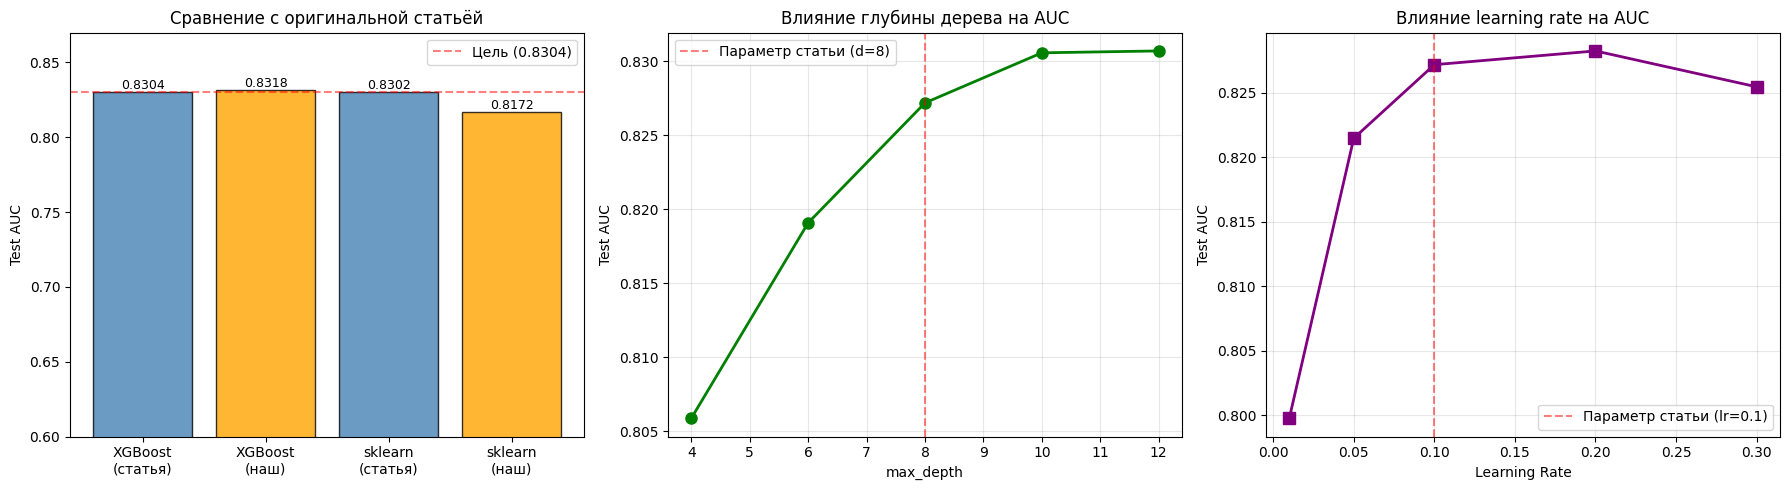

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ['XGBoost\n(статья)', 'XGBoost\n(наш)', 'sklearn\n(статья)', 'sklearn\n(наш)']
aucs = [0.8304, xgb_auc, 0.8302, sk_auc]
colors = ['steelblue', 'orange', 'steelblue', 'orange']

axes[0].bar(methods, aucs, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_ylim(0.6, 0.87)
axes[0].set_title('Сравнение с оригинальной статьёй', fontsize=12)
axes[0].set_ylabel('Test AUC')
axes[0].axhline(y=0.8304, color='red', linestyle='--', alpha=0.5, label='Цель (0.8304)')
axes[0].legend()
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)


axes[1].plot(depths, depth_aucs, 'o-', color='green', linewidth=2, markersize=8)
axes[1].axvline(x=8, color='red', linestyle='--', alpha=0.5, label='Параметр статьи (d=8)')
axes[1].set_title('Влияние глубины дерева на AUC', fontsize=12)
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Test AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


axes[2].plot(lrs, lr_aucs, 's-', color='purple', linewidth=2, markersize=8)
axes[2].axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Параметр статьи (lr=0.1)')
axes[2].set_title('Влияние learning rate на AUC', fontsize=12)
axes[2].set_xlabel('Learning Rate')
axes[2].set_ylabel('Test AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


## 9. Итоговая таблица всех экспериментов

In [13]:

print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ')

print()
print('1. ВОСПРОИЗВЕДЕНИЕ (Таблица 3 из статьи):')
print(f'   XGBoost:    AUC={xgb_auc:.4f} (статья: 0.8304, отклонение: {abs(xgb_auc-0.8304):.4f})')
print(f'   sklearn:    AUC={sk_auc:.4f} (статья: 0.8302)')
print(f'   colsample:  AUC={col_auc:.4f} (статья: 0.8245)')
print()
print('2. лучший max_depth:')
best_depth_idx = np.argmax(depth_aucs)
print(f'   max_depth={depths[best_depth_idx]}: AUC={depth_aucs[best_depth_idx]:.4f} (оригинал d=8: {depth_aucs[depths.index(8)]:.4f})')
print()
print('3. лучший learning rate:')
best_lr_idx = np.argmax(lr_aucs)
print(f'   lr={lrs[best_lr_idx]}: AUC={lr_aucs[best_lr_idx]:.4f} (оригинал lr=0.1: {lr_aucs[lrs.index(0.1)]:.4f})')

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

1. ВОСПРОИЗВЕДЕНИЕ (Таблица 3 из статьи):
   XGBoost:    AUC=0.8318 (статья: 0.8304, отклонение: 0.0014)
   sklearn:    AUC=0.8172 (статья: 0.8302)
   colsample:  AUC=0.8294 (статья: 0.8245)

2. лучший max_depth:
   max_depth=12: AUC=0.8307 (оригинал d=8: 0.8272)

3. лучший learning rate:
   lr=0.2: AUC=0.8282 (оригинал lr=0.1: 0.8272)


## 10. LightGBM - сравнение

In [14]:
import lightgbm as lgb

print('LightGBM (для сравнения с XGBoost)')

lgb_model = lgb.LGBMClassifier(
    max_depth=8,
    learning_rate=0.1,
    n_estimators=500,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

t0 = time.time()
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - t0

lgb_pred = lgb_model.predict_proba(X_test)[:, 1]
lgb_auc = roc_auc_score(y_test, lgb_pred)

print(f'LightGBM Test AUC:        {lgb_auc:.4f}')
print(f'LightGBM Time per Tree:   {lgb_time/500:.4f} сек')
print(f'XGBoost  Test AUC:        {xgb_auc:.4f}')
print(f'XGBoost  Time per Tree:   {time_per_tree:.4f} сек')
print()
print(f'LightGBM быстрее XGBoost в {time_per_tree/(lgb_time/500):.1f}x раз')

LightGBM (для сравнения с XGBoost)
LightGBM Test AUC:        0.8237
LightGBM Time per Tree:   0.1331 сек
XGBoost  Test AUC:        0.8318
XGBoost  Time per Tree:   0.1941 сек

LightGBM быстрее XGBoost в 1.5x раз
